# Render Custom World
Visualize a custom world `.txt` file as it would appear in Crafter.

In [ ]:
# === Change this path to your custom world file ===
WORLD_PATH = '../custom_worlds/arena.txt'
TILE_PX = 16  # pixels per tile (increase for higher res)

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import crafter

# Tile codes — must match embodied/envs/crafter.py
MATERIAL_CODES = {
    '.': 'water', 'W': 'water', 'G': 'grass', 'T': 'tree',
    'S': 'stone', 'P': 'path',  'N': 'sand',  'L': 'lava',
    'C': 'coal',  'I': 'iron',  'D': 'diamond', 'A': 'table', 'F': 'furnace',
}
OBJECT_CODES = {'@': 'cow', 'Z': 'zombie', 'K': 'skeleton'}

In [3]:
# Parse the world file
with open(WORLD_PATH) as f:
    lines = [line.strip() for line in f if line.strip()]
grid = [line.split() for line in lines]
n_rows, n_cols = len(grid), len(grid[0])
print(f'World: {os.path.basename(WORLD_PATH)}  — {n_cols}x{n_rows} tiles')

# Create a throwaway crafter env just to access its texture atlas
env = crafter.Env(area=(4, 4), size=(64, 64), reward=False, seed=0)
env.reset()
textures = env._textures

# Build image in crafter's native (x, y) axis order, then transpose once at the end.
# Grid rows = y, grid cols = x.  Canvas indexed as [x, y, c].
unit = (TILE_PX, TILE_PX)
canvas = np.zeros((n_cols * TILE_PX, n_rows * TILE_PX, 3), dtype=np.uint8)

for row_idx, row in enumerate(grid):       # row_idx = y
    for col_idx, ch in enumerate(row):      # col_idx = x
        px, py = col_idx * TILE_PX, row_idx * TILE_PX

        # Material texture (objects sit on grass)
        mat_name = 'grass' if ch in OBJECT_CODES else MATERIAL_CODES.get(ch, 'grass')
        tex = textures.get(mat_name, unit)
        canvas[px:px + TILE_PX, py:py + TILE_PX] = tex[..., :3]

        # Alpha-composite object sprite on top
        if ch in OBJECT_CODES:
            obj_tex = textures.get(OBJECT_CODES[ch], unit)
            if obj_tex.shape[-1] == 4:
                a = obj_tex[..., 3:].astype(np.float32) / 255
                fg = obj_tex[..., :3].astype(np.float32)
                bg = canvas[px:px + TILE_PX, py:py + TILE_PX].astype(np.float32)
                canvas[px:px + TILE_PX, py:py + TILE_PX] = (a * fg + (1 - a) * bg).astype(np.uint8)
            else:
                canvas[px:px + TILE_PX, py:py + TILE_PX] = obj_tex[..., :3]

# Transpose so rows=y, cols=x (standard image axes)
image = canvas.transpose(1, 0, 2)
print(f'Image: {image.shape}, dtype={image.dtype}')

World: maze.txt  — 12x11 tiles
Image: (176, 192, 3), dtype=uint8


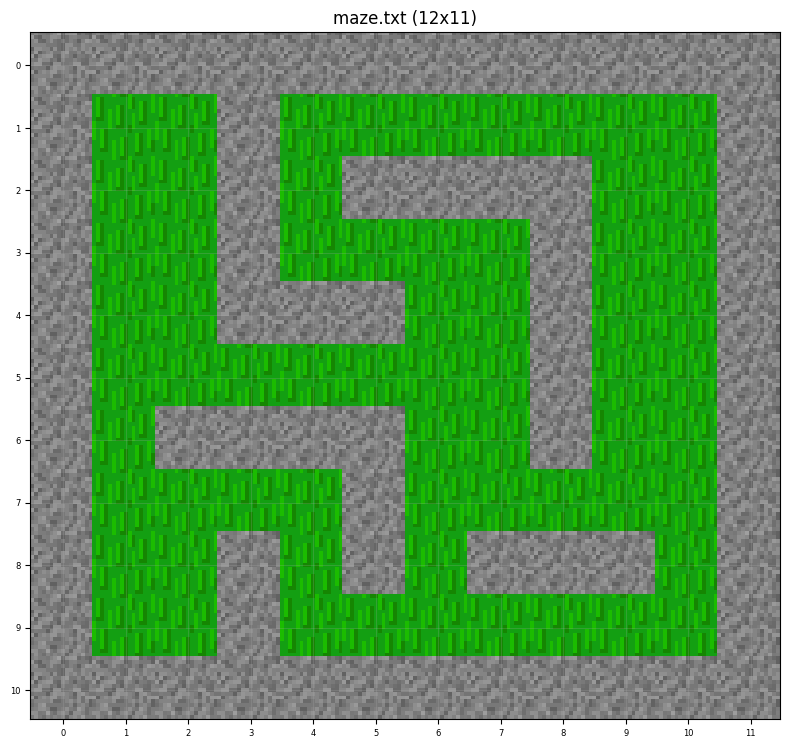

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(image)
ax.set_title(f"{os.path.basename(WORLD_PATH)} ({n_cols}x{n_rows})")
ax.set_xticks(np.arange(0, n_cols * TILE_PX, TILE_PX) + TILE_PX / 2,
              labels=range(n_cols), fontsize=6)
ax.set_yticks(np.arange(0, n_rows * TILE_PX, TILE_PX) + TILE_PX / 2,
              labels=range(n_rows), fontsize=6)
ax.grid(True, alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

In [5]:
# Text grid + legend for reference
print('Legend:')
for code, name in sorted(MATERIAL_CODES.items()):
    print(f'  {code} = {name}')
for code, name in sorted(OBJECT_CODES.items()):
    print(f'  {code} = {name} (on grass)')
print()
for row in grid:
    print(' '.join(row))

Legend:
  . = water
  A = table
  C = coal
  D = diamond
  F = furnace
  G = grass
  I = iron
  L = lava
  N = sand
  P = path
  S = stone
  T = tree
  W = water
  @ = cow (on grass)
  K = skeleton (on grass)
  Z = zombie (on grass)

S S S S S S S S S S S S
S G G S G G G G G G G S
S G G S G S S S S G G S
S G G S G G G G S G G S
S G G S S S G G S G G S
S G G G G G G G S G G S
S G S S S S G G S G G S
S G G G G S G G G G G S
S G G S G S G S S S G S
S G G S G G G G G G G S
S S S S S S S S S S S S
